In [1]:
import os
import numpy as np
import math
import matplotlib.pyplot as plt

import scipy as sp
import scipy.linalg
import scipy.optimize

import glob

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    'font.size'  : 20
})

In [3]:
def format_print(cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'

def format_print_w_exact(exact, cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, 
                                            width=i+1)+'('+str(round(tmp))+')'+': '+'{num:.{width}f}'.format(num=(exact-cen)/err, 
                                                                                                             width=i+1)+' sigma'

In [4]:
def f(t, nmax, T):
    res = 0.0
    for n in range(1,nmax):
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*t )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(T-t) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(t+T) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(2*T-t) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(t+2*T) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(3*T-t) )
    return res/(8.0*np.pi)

In [5]:
gsq=0.050000
beta=1.0/gsq

In [6]:
masses_=[]

In [7]:
beta

20.0

In [8]:
T=16
Nt=24 # 240

In [9]:
l1_1 = np.loadtxt("prop_gauge_gsq0.050000_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l2_1 = np.loadtxt("prop_gauge_gsq0.050000_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l4_1 = np.loadtxt("prop_gauge_gsq0.050000_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l8_1 = np.loadtxt("prop_gauge_gsq0.050000_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")

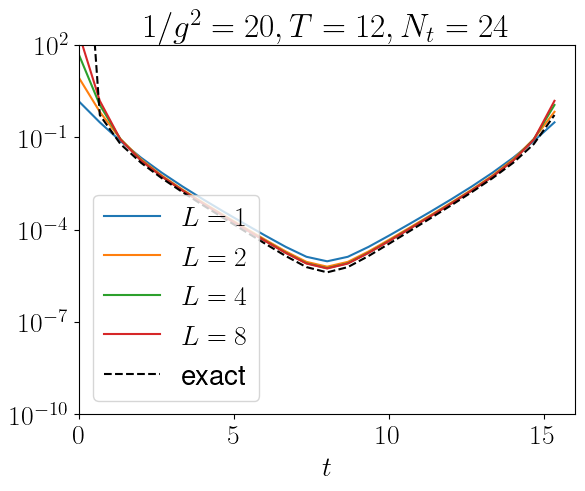

In [10]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, beta*l1_1, label="$L=1$" )
plt.plot( xx, beta*l2_1, label="$L=2$" )
plt.plot( xx, beta*l4_1, label="$L=4$" )
plt.plot( xx, beta*l8_1, label="$L=8$" )
# plt.plot( xx, l12_1, label="$L=16$" )

yy= f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-10, 1.0e2)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [11]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(8.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [12]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [13]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

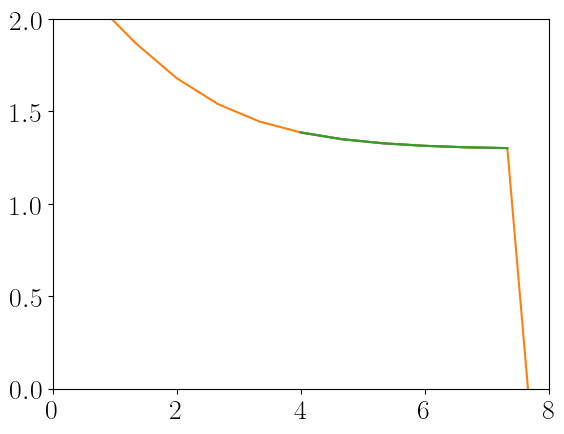

In [14]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [15]:
masses_.append([1, Nt, opt[0][0]])

In [16]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [17]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

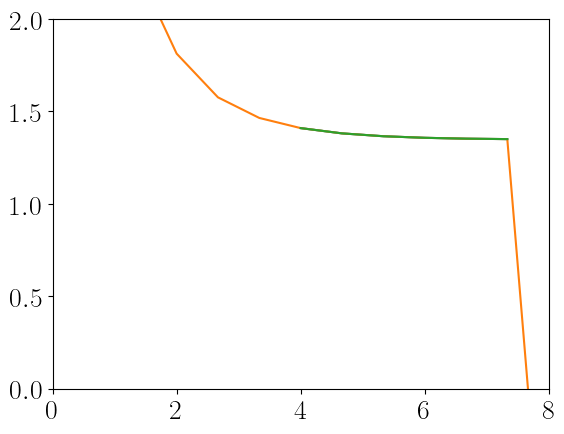

In [18]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [19]:
masses_.append([2, Nt, opt[0][0]])

In [20]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [21]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

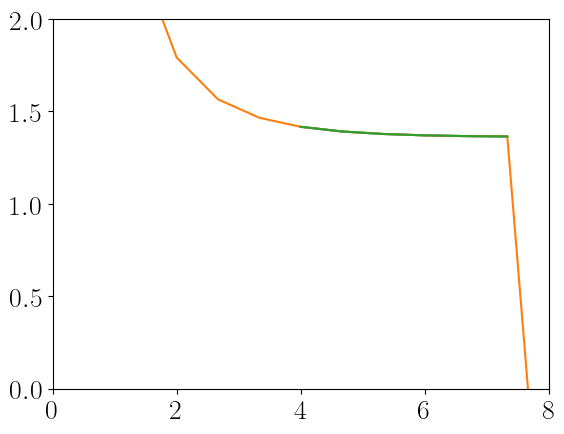

In [22]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [23]:
masses_.append([4, Nt, opt[0][0]])

In [24]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [25]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

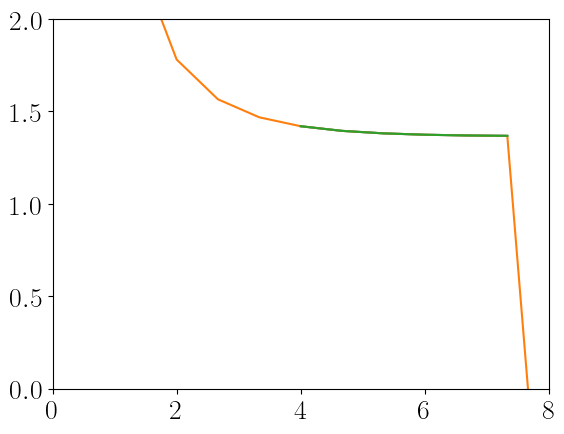

In [26]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [27]:
masses_.append([8, Nt, opt[0][0]])

In [28]:
T=16
Nt=48 # 240

In [29]:
l1_1 = np.loadtxt("prop_gauge_gsq0.050000_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l2_1 = np.loadtxt("prop_gauge_gsq0.050000_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l4_1 = np.loadtxt("prop_gauge_gsq0.050000_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l8_1 = np.loadtxt("prop_gauge_gsq0.050000_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")

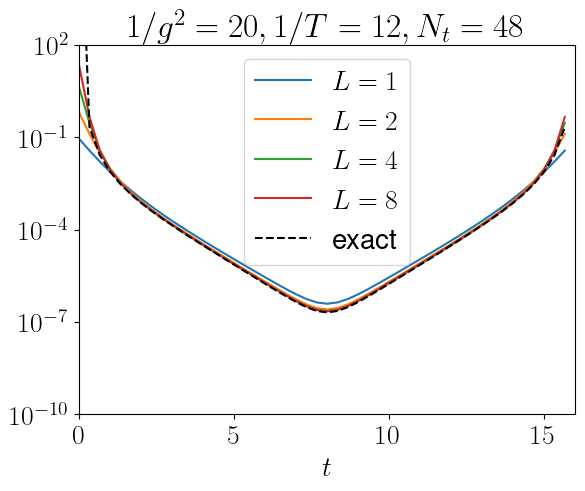

In [30]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
plt.plot( xx, l8_1, label="$L=8$" )
# plt.plot( xx, l12_1, label="$L=16$" )

yy= (1.0/beta)*f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-10, 1.0e2)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [31]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(8.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [32]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [33]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

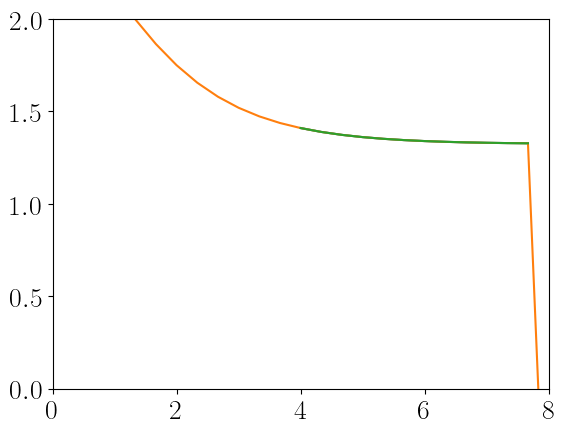

In [34]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [35]:
masses_.append([1, Nt, opt[0][0]])

In [36]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [37]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

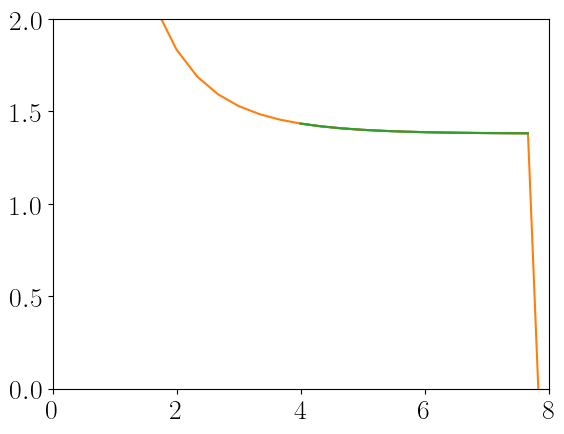

In [38]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [39]:
masses_.append([2, Nt, opt[0][0]])

In [40]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [41]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

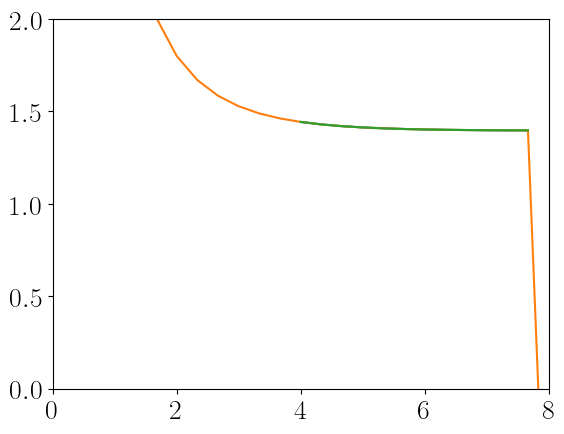

In [42]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [43]:
masses_.append([4, Nt, opt[0][0]])

In [44]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [45]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

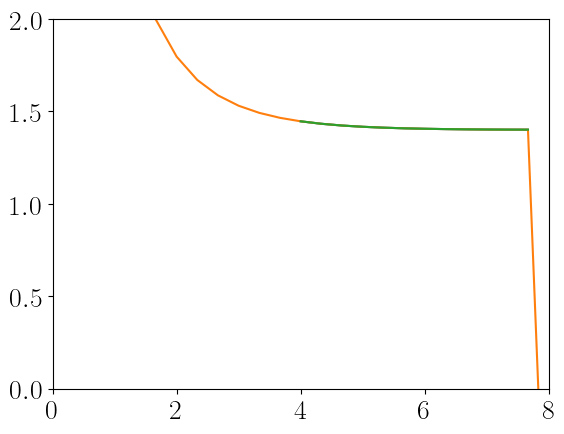

In [46]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [47]:
masses_.append([8, Nt, opt[0][0]])

In [48]:
T=16
Nt=64 # 240

In [49]:
l1_1 = np.loadtxt("prop_gauge_gsq0.050000_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l2_1 = np.loadtxt("prop_gauge_gsq0.050000_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l4_1 = np.loadtxt("prop_gauge_gsq0.050000_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l8_1 = np.loadtxt("prop_gauge_gsq0.050000_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")

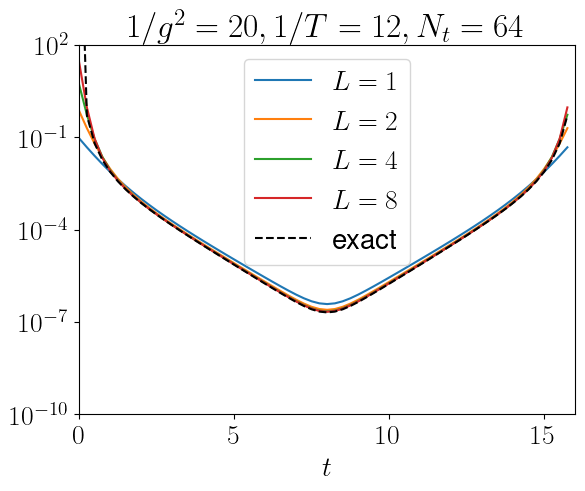

In [50]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
plt.plot( xx, l8_1, label="$L=8$" )
# plt.plot( xx, l12_1, label="$L=16$" )

yy= (1.0/beta)*f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-10, 1.0e2)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [51]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(8.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [52]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [53]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

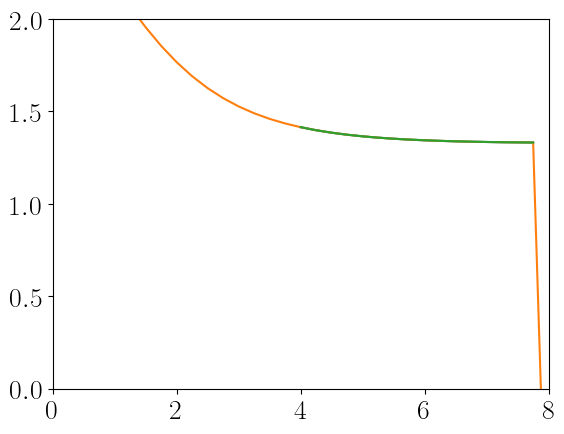

In [54]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [55]:
masses_.append([1, Nt, opt[0][0]])

In [56]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [57]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

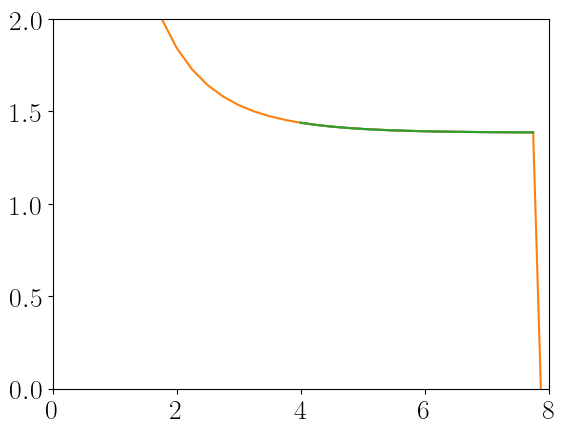

In [58]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [59]:
masses_.append([2, Nt, opt[0][0]])

In [60]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [61]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

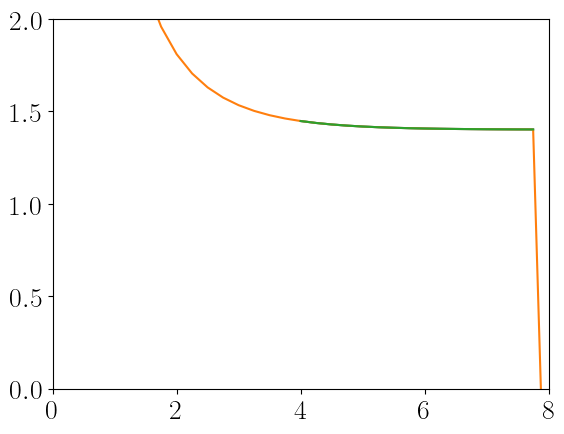

In [62]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [63]:
masses_.append([4, Nt, opt[0][0]])

In [64]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [65]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

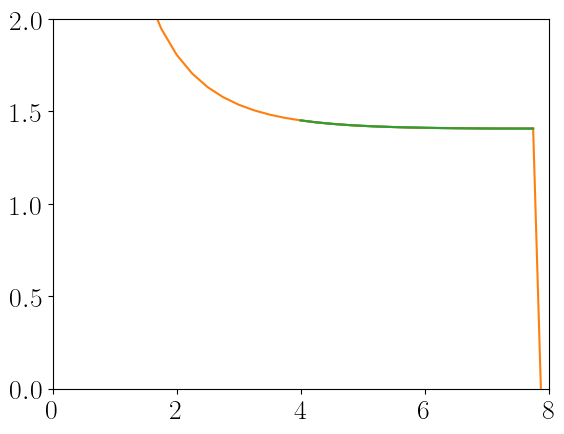

In [66]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [67]:
masses_.append([8, Nt, opt[0][0]])

In [68]:
T=16
Nt=96 # 240

In [69]:
l1_1 = np.loadtxt("prop_gauge_gsq0.050000_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l2_1 = np.loadtxt("prop_gauge_gsq0.050000_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l4_1 = np.loadtxt("prop_gauge_gsq0.050000_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l8_1 = np.loadtxt("prop_gauge_gsq0.050000_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")

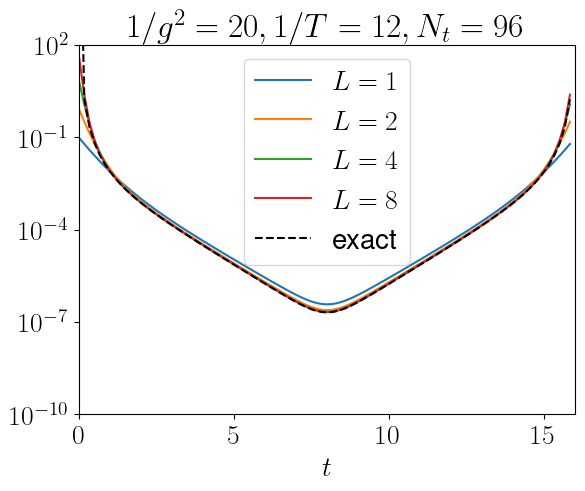

In [70]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
plt.plot( xx, l8_1, label="$L=8$" )
# plt.plot( xx, l12_1, label="$L=16$" )

yy= (1.0/beta)*f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-10, 1.0e2)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [71]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(8.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [72]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [73]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

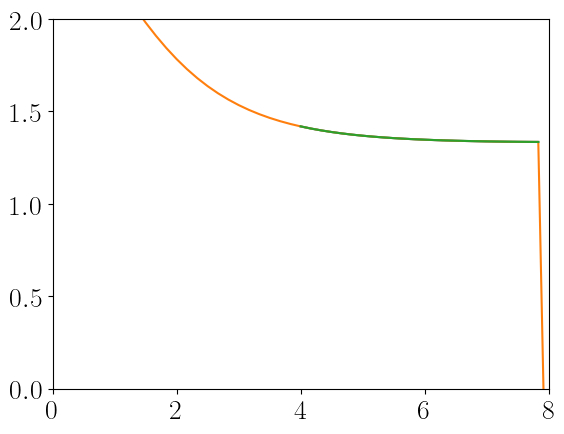

In [74]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [75]:
masses_.append([1, Nt, opt[0][0]])

In [76]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [77]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

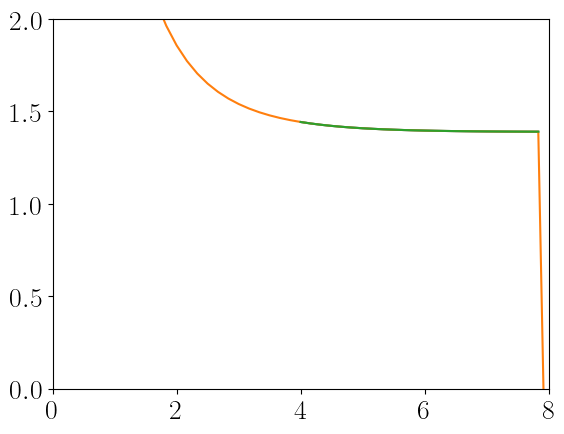

In [78]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [79]:
masses_.append([2, Nt, opt[0][0]])

In [80]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [81]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

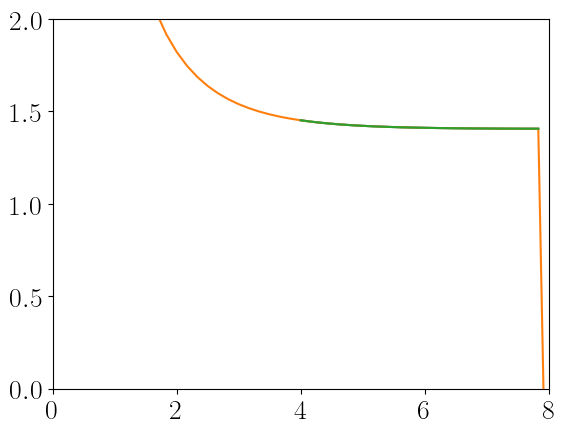

In [82]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [83]:
masses_.append([4, Nt, opt[0][0]])

In [84]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [85]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

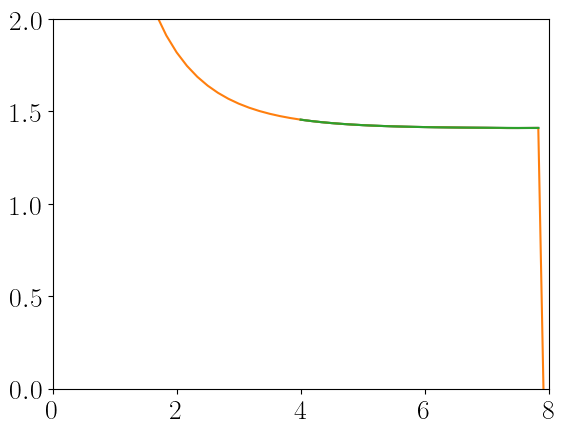

In [86]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [87]:
masses_.append([8, Nt, opt[0][0]])

In [88]:
T=16
Nt=120 # 240

In [89]:
l1_1 = np.loadtxt("prop_gauge_gsq0.050000_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l2_1 = np.loadtxt("prop_gauge_gsq0.050000_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l4_1 = np.loadtxt("prop_gauge_gsq0.050000_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l8_1 = np.loadtxt("prop_gauge_gsq0.050000_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")

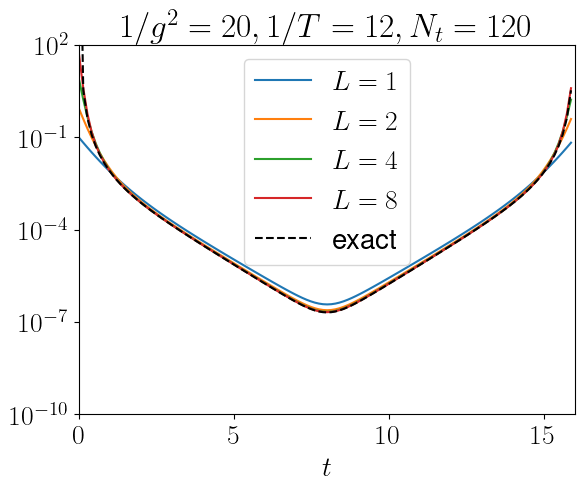

In [90]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
plt.plot( xx, l8_1, label="$L=8$" )
# plt.plot( xx, l12_1, label="$L=16$" )

yy= (1.0/beta)*f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-10, 1.0e2)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [91]:
at = T/Nt

# fitm = int(4.0 * Nt/T)
# fitM = int(5.5 * Nt/T)

fitm = int(4.0 * Nt/T)
fitM = int(8.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [92]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [93]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

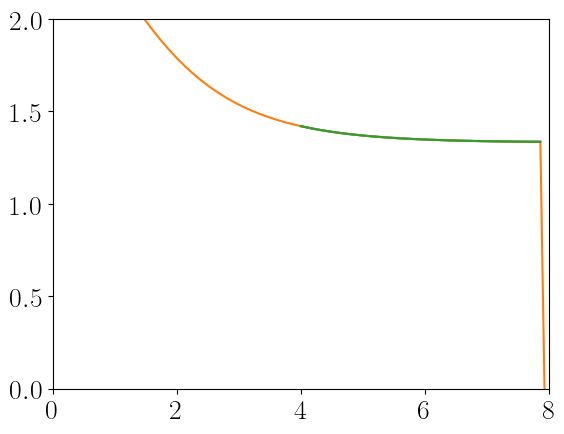

In [94]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [95]:
masses_.append([1, Nt, opt[0][0]])

In [96]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [97]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

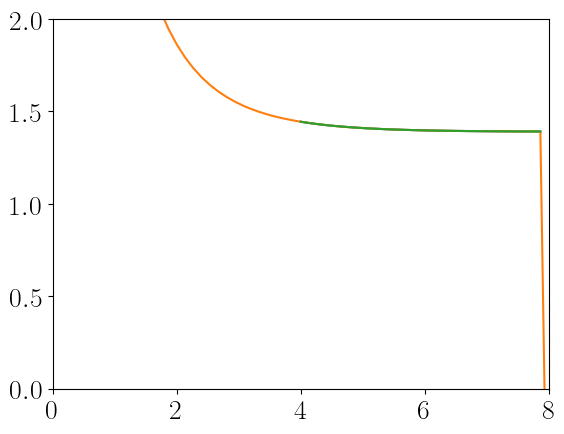

In [98]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [99]:
masses_.append([2, Nt, opt[0][0]])

In [100]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [101]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

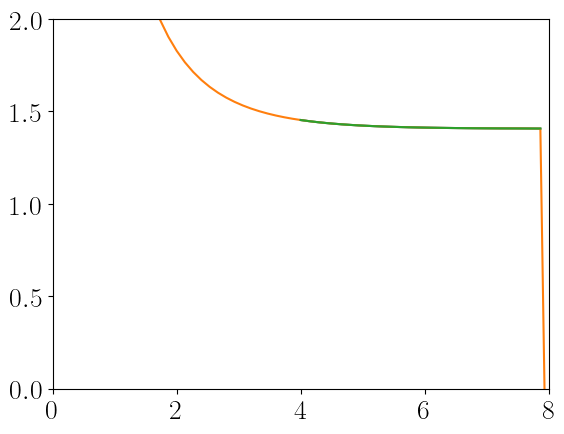

In [102]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [103]:
masses_.append([4, Nt, opt[0][0]])

In [104]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [105]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

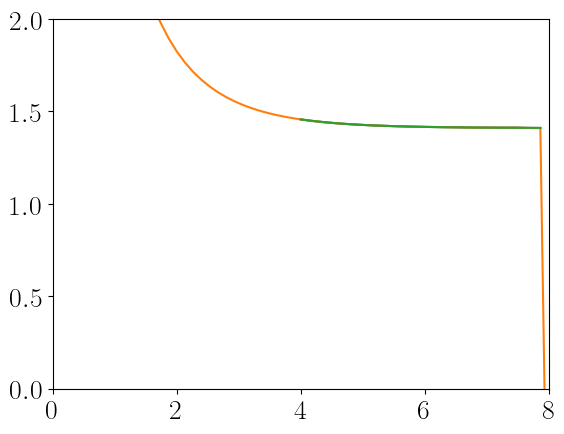

In [106]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM][:-1], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [107]:
masses_.append([8, Nt, opt[0][0]])

In [108]:
masses = np.array(masses_)

In [109]:
ells={1:1.107148717794090e+00, 
      2:5.909464448075019e-01, 
      4:2.994744726728921e-01,
      8:1.502274914280941e-01, 
      12:1.002118985797942e-01
     }

In [110]:
masses

array([[  1.        ,  24.        ,   1.29420291],
       [  2.        ,  24.        ,   1.3473482 ],
       [  4.        ,  24.        ,   1.36202915],
       [  8.        ,  24.        ,   1.36554246],
       [  1.        ,  48.        ,   1.32352646],
       [  2.        ,  48.        ,   1.38032987],
       [  4.        ,  48.        ,   1.39623359],
       [  8.        ,  48.        ,   1.40024677],
       [  1.        ,  64.        ,   1.32812254],
       [  2.        ,  64.        ,   1.38554125],
       [  4.        ,  64.        ,   1.40167152],
       [  8.        ,  64.        ,   1.40625459],
       [  1.        ,  96.        ,   1.3314538 ],
       [  2.        ,  96.        ,   1.38933006],
       [  4.        ,  96.        ,   1.40562823],
       [  8.        ,  96.        ,   1.4095583 ],
       [  1.        , 120.        ,   1.33241575],
       [  2.        , 120.        ,   1.39043411],
       [  4.        , 120.        ,   1.40676039],
       [  8.        , 120.     

In [111]:
a_s = np.array([ [ ells[elem[0]], T/elem[1] ] for elem in masses ])

In [112]:
def fitter( x, c0, cx, ct ):
    return c0 + cx*x[0]**2 + ct*x[1]**2

In [113]:
opt1= sp.optimize.curve_fit( fitter, a_s.T, masses.T[2],
                       p0=(np.sqrt(2.0), 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [114]:
opt1

(array([ 1.41350099, -0.06373582, -0.09995079]),
 array([[ 1.23355172e-01, -9.15653928e-02, -2.61687592e-01],
        [-9.15653928e-02,  2.17076163e-01,  1.01989558e-16],
        [-2.61687592e-01,  1.01989558e-16,  1.97169352e+00]]),
 {'fvec': array([-3.25047447e-03, -5.27457935e-04,  1.33311993e-03,  2.09754815e-03,
          7.42903956e-04, -1.92200746e-04,  4.45611395e-04,  7.10166577e-04,
          1.00553700e-03, -5.44862327e-04, -1.33599052e-04, -4.38932112e-04,
          1.14479370e-03, -8.63156024e-04, -6.19794484e-04, -2.72134062e-04,
          1.18235456e-03, -9.67697612e-04, -7.52444230e-04, -9.92822084e-05]),
  'nfev': 9,
  'fjac': array([[-4.47213597e+00,  2.23606798e-01,  2.23606798e-01,
           2.23606798e-01,  2.23606798e-01,  2.23606798e-01,
           2.23606798e-01,  2.23606798e-01,  2.23606798e-01,
           2.23606798e-01,  2.23606798e-01,  2.23606798e-01,
           2.23606798e-01,  2.23606798e-01,  2.23606798e-01,
           2.23606798e-01,  2.23606798e-01,  

In [115]:
masses2_ = []
for elem in masses:
    if elem[0]!=1:
        masses2_.append(elem)
masses2=np.array(masses2_)

In [116]:
masses2

array([[  2.        ,  24.        ,   1.3473482 ],
       [  4.        ,  24.        ,   1.36202915],
       [  8.        ,  24.        ,   1.36554246],
       [  2.        ,  48.        ,   1.38032987],
       [  4.        ,  48.        ,   1.39623359],
       [  8.        ,  48.        ,   1.40024677],
       [  2.        ,  64.        ,   1.38554125],
       [  4.        ,  64.        ,   1.40167152],
       [  8.        ,  64.        ,   1.40625459],
       [  2.        ,  96.        ,   1.38933006],
       [  4.        ,  96.        ,   1.40562823],
       [  8.        ,  96.        ,   1.4095583 ],
       [  2.        , 120.        ,   1.39043411],
       [  4.        , 120.        ,   1.40676039],
       [  8.        , 120.        ,   1.41038496]])

In [117]:
a_s2 = np.array([ [ ells[elem[0]], T/elem[1] ] for elem in masses2 ])

In [118]:
opt2= sp.optimize.curve_fit( fitter, a_s2.T, masses2.T[2],
                       p0=(np.sqrt(2.0), 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [119]:
opt2

(array([ 1.41357194, -0.06076379, -0.1035155 ]),
 array([[ 1.92483565e-01, -5.16876227e-01, -3.48917159e-01],
        [-5.16876227e-01,  3.36018510e+00,  1.59196794e-07],
        [-3.48917159e-01,  1.59196794e-07,  2.62892731e+00]]),
 {'fvec': array([-1.00293136e-03,  8.63064573e-05,  6.51261696e-04,  5.20561901e-04,
          3.87033990e-04,  4.52116195e-04,  3.41184747e-04, -1.88920303e-05,
         -5.23698068e-04,  1.46665641e-04, -3.81312872e-04, -2.33125427e-04,
          7.77711353e-05, -4.78315536e-04, -2.46264912e-05]),
  'nfev': 9,
  'fjac': array([[-3.87298333e+00,  2.58198887e-01,  2.58198893e-01,
           2.58198890e-01,  2.58198890e-01,  2.58198890e-01,
           2.58198890e-01,  2.58198890e-01,  2.58198890e-01,
           2.58198890e-01,  2.58198890e-01,  2.58198890e-01,
           2.58198890e-01,  2.58198890e-01,  2.58198890e-01],
         [-5.14031043e-01, -6.16752205e-01,  4.01705505e-01,
          -1.38759958e-01, -1.38759958e-01, -1.38759958e-01,
          -2.175

In [133]:
opt3= sp.optimize.curve_fit( fitter, a_s[4:].T, masses[4:].T[2],
                       p0=(np.sqrt(2.0), 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [134]:
opt3

(array([ 1.41426822, -0.0647819 , -0.10629625]),
 array([[ 2.51563235e-01, -1.14456721e-01, -2.56944321e+00],
        [-1.14456721e-01,  2.71345137e-01, -3.05104480e-15],
        [-2.56944321e+00, -3.05104480e-15,  4.68948132e+01]]),
 {'fvec': array([-4.77189161e-04, -4.95337560e-04,  4.13967719e-04,  7.48732588e-04,
          9.39038290e-05, -5.39539197e-04,  1.43217216e-04, -9.19061565e-05,
          4.53489056e-04, -6.37504362e-04, -1.22649685e-04,  2.95220426e-04,
          5.54504537e-04, -6.78591332e-04, -1.91844813e-04,  5.31526896e-04]),
  'nfev': 9,
  'fjac': array([[-3.99999999e+00,  2.50000000e-01,  2.50000000e-01,
           2.50000000e-01,  2.50000000e-01,  2.50000000e-01,
           2.50000000e-01,  2.50000000e-01,  2.50000000e-01,
           2.50000000e-01,  2.50000000e-01,  2.50000000e-01,
           2.50000000e-01,  2.50000000e-01,  2.50000000e-01,
           2.50000000e-01],
         [-1.68724927e+00,  1.91972482e+00,  2.56766263e-01,
           2.91727910e-01, -3.350

In [142]:
masses[4:]

array([[  1.        ,  48.        ,   1.32352646],
       [  2.        ,  48.        ,   1.38032987],
       [  4.        ,  48.        ,   1.39623359],
       [  8.        ,  48.        ,   1.40024677],
       [  1.        ,  64.        ,   1.32812254],
       [  2.        ,  64.        ,   1.38554125],
       [  4.        ,  64.        ,   1.40167152],
       [  8.        ,  64.        ,   1.40625459],
       [  1.        ,  96.        ,   1.3314538 ],
       [  2.        ,  96.        ,   1.38933006],
       [  4.        ,  96.        ,   1.40562823],
       [  8.        ,  96.        ,   1.4095583 ],
       [  1.        , 120.        ,   1.33241575],
       [  2.        , 120.        ,   1.39043411],
       [  4.        , 120.        ,   1.40676039],
       [  8.        , 120.        ,   1.41038496]])

In [141]:
masses2[3:]

array([[  2.        ,  48.        ,   1.38032987],
       [  4.        ,  48.        ,   1.39623359],
       [  8.        ,  48.        ,   1.40024677],
       [  2.        ,  64.        ,   1.38554125],
       [  4.        ,  64.        ,   1.40167152],
       [  8.        ,  64.        ,   1.40625459],
       [  2.        ,  96.        ,   1.38933006],
       [  4.        ,  96.        ,   1.40562823],
       [  8.        ,  96.        ,   1.4095583 ],
       [  2.        , 120.        ,   1.39043411],
       [  4.        , 120.        ,   1.40676039],
       [  8.        , 120.        ,   1.41038496]])

In [136]:
opt4= sp.optimize.curve_fit( fitter, a_s2[3:].T, masses2[3:].T[2],
                       p0=(np.sqrt(2.0), 0.0, 0.0 ), 
                       full_output=True, absolute_sigma=True )

In [137]:
opt4

(array([ 1.41408949, -0.06196918, -0.10998069]),
 array([[ 3.70430299e-01, -6.46094115e-01, -3.42593253e+00],
        [-6.46094115e-01,  4.20022778e+00, -1.77836621e-15],
        [-3.42593253e+00, -1.77836621e-15,  6.25265598e+01]]),
 {'fvec': array([-1.01195389e-04,  7.81169096e-05,  2.24101393e-04,  3.37077135e-05,
         -1.35288548e-05, -4.37432613e-04,  6.36745043e-05, -1.51463799e-04,
          7.76259249e-05,  5.94319370e-05, -1.83814524e-04,  3.50776799e-04]),
  'nfev': 9,
  'fjac': array([[-3.46410161e+00,  2.88675135e-01,  2.88675135e-01,
           2.88675135e-01,  2.88675135e-01,  2.88675135e-01,
           2.88675135e-01,  2.88675135e-01,  2.88675135e-01,
           2.88675135e-01,  2.88675135e-01,  2.88675135e-01],
         [-5.32860546e-01,  4.87936806e-01,  3.58705167e-01,
          -3.10745122e-01,  2.21153126e-01,  3.58705167e-01,
          -3.10745122e-01,  2.21153126e-01,  3.58705167e-01,
          -3.10745122e-01,  2.21153126e-01,  3.58705167e-01],
         [-1.8

In [138]:
abs(opt4[0][0]-opt3[0][0])

0.00017872724698309028

In [139]:
format_print_w_exact( np.sqrt(2), opt4[0][0], abs(opt4[0][0]-opt3[0][0]) )

'1.41409(18): 0.69421 sigma'

In [125]:
lim = fitter( [0.0, a_s[16:][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )

In [126]:
cs_default = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2',
 '#7f7f7f', '#bcbd22', '#17becf']

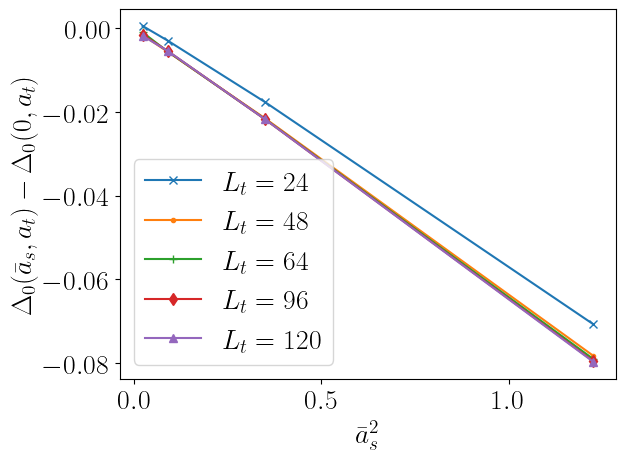

In [127]:
lim = fitter( [0.0, a_s[:4][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[:4].T[0]**2, masses.T[2][:4]-lim, label="$L_t=24$", marker='x', c=cs_default[0] )

lim = fitter( [0.0, a_s[4:8][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[4:8].T[0]**2, masses.T[2][4:8]-lim, label="$L_t=48$", marker='.', c=cs_default[1] )

lim = fitter( [0.0, a_s[8:12][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[8:12].T[0]**2, masses.T[2][8:12]-lim, label="$L_t=64$", marker='+', c=cs_default[2] )

lim = fitter( [0.0, a_s[12:16][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[12:16].T[0]**2, masses.T[2][12:16]-lim, label="$L_t=96$", marker='d', c=cs_default[3] )

lim = fitter( [0.0, a_s[16:][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[16:].T[0]**2, masses.T[2][16:]-lim, label="$L_t=120$", marker='^', c=cs_default[4] )

plt.legend()

plt.xlabel("$\\bar{a}_s^2$")
plt.ylabel("$\\Delta_0(\\bar{a}_s, a_t) - \\Delta_0(0, a_t)$")

plt.savefig("ellbar_scaling_gauge.pdf", bbox_inches="tight")

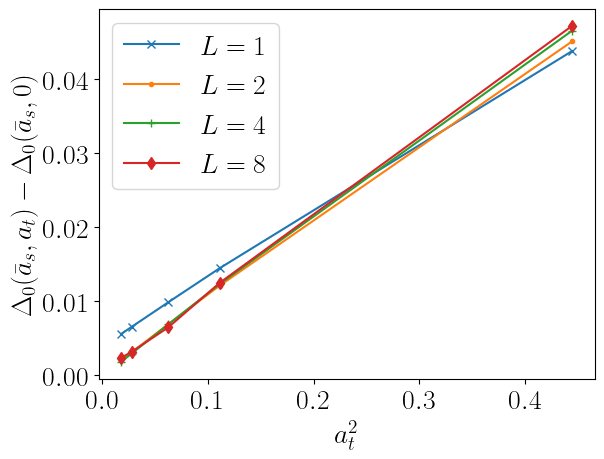

In [128]:
ibase=0
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=1$", marker='x' )

ibase=1
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=2$", marker='.' )

ibase=2
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=4$", marker='+' )

ibase=3
lim = fitter( [a_s[ibase::4][0][0], 0.0], opt4[0][0], opt4[0][1], opt4[0][2] )
plt.plot( a_s[ibase::4].T[1]**2, lim-masses.T[2][ibase::4], label="$L=8$", marker='d' )

# plt.xscale("log")
# plt.yscale("log")
plt.legend()

plt.xlabel("$a_t^2$")
plt.ylabel("$\\Delta_0(\\bar{a}_s, a_t) - \\Delta_0(\\bar{a}_s, 0)$")

plt.savefig("at_scaling_gauge.pdf", bbox_inches="tight")

In [129]:
a_s

array([[1.10714872, 0.66666667],
       [0.59094644, 0.66666667],
       [0.29947447, 0.66666667],
       [0.15022749, 0.66666667],
       [1.10714872, 0.33333333],
       [0.59094644, 0.33333333],
       [0.29947447, 0.33333333],
       [0.15022749, 0.33333333],
       [1.10714872, 0.25      ],
       [0.59094644, 0.25      ],
       [0.29947447, 0.25      ],
       [0.15022749, 0.25      ],
       [1.10714872, 0.16666667],
       [0.59094644, 0.16666667],
       [0.29947447, 0.16666667],
       [0.15022749, 0.16666667],
       [1.10714872, 0.13333333],
       [0.59094644, 0.13333333],
       [0.29947447, 0.13333333],
       [0.15022749, 0.13333333]])

In [130]:
fitter( [0.0, a_s[16:][0][1]], opt4[0][0], opt4[0][1], opt4[0][2] )

1.4121625596831142

In [131]:
opt1[0][0]

1.4134999548038671

In [132]:
masses.T[2][::4]

array([1.29419987, 1.32352563, 1.32812044, 1.33145172, 1.33241985])

In [133]:
a_s[::3].T[0]

array([1.10714872, 0.15022749, 0.29947447, 0.59094644, 1.10714872,
       0.15022749, 0.29947447])

In [134]:
a_s[4:8]

array([[1.10714872, 0.33333333],
       [0.59094644, 0.33333333],
       [0.29947447, 0.33333333],
       [0.15022749, 0.33333333]])

In [135]:
a_s

array([[1.10714872, 0.66666667],
       [0.59094644, 0.66666667],
       [0.29947447, 0.66666667],
       [0.15022749, 0.66666667],
       [1.10714872, 0.33333333],
       [0.59094644, 0.33333333],
       [0.29947447, 0.33333333],
       [0.15022749, 0.33333333],
       [1.10714872, 0.25      ],
       [0.59094644, 0.25      ],
       [0.29947447, 0.25      ],
       [0.15022749, 0.25      ],
       [1.10714872, 0.16666667],
       [0.59094644, 0.16666667],
       [0.29947447, 0.16666667],
       [0.15022749, 0.16666667],
       [1.10714872, 0.13333333],
       [0.59094644, 0.13333333],
       [0.29947447, 0.13333333],
       [0.15022749, 0.13333333]])